[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter15_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 15: LLMs and Sentiment Analysis

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces every chart and number of Lecture 15:
- labelled financial texts: Financial PhraseBank (Malo et al., 2014) and Twitter Financial News (2022);
- dictionaries (Harvard IV-4, Loughran–McDonald), VADER, FinBERT, zero-shot LLMs (Qwen2.5, 0.5B–14B), embeddings;
- a look-ahead test: does an LLM already know what markets did?
- FNSPID headlines about 17 large US stocks and daily prices (course repository, `data/market`): from sentiment to a trading signal.

The language-model scores are read from the tables published with the Quantlets of Chapter 15; set `RECOMPUTE = True` to recompute them (hours without a GPU).

In [1]:
import os
import io
import re
import sys
import json
import time
import zipfile
import subprocess
import urllib.request
for pkg, mod in (('pysentiment2', 'pysentiment2'), ('transformers', 'transformers')):
    try:
        __import__(mod)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

PHRASEBANK_URL = ('https://huggingface.co/datasets/takala/financial_phrasebank/resolve/main/data/'
                  'FinancialPhraseBank-v1.0.zip')
TWITTER_URL = 'https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment/resolve/main/'
FNSPID_URLS = ['https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/All_external.csv',
               'https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/nasdaq_exteral_data.csv']
LABELS = ['negative', 'neutral', 'positive']
TW_MAP = {0: 'negative', 1: 'positive', 2: 'neutral'}          # Bearish, Bullish, Neutral
AGREE = ['50Agree', '66Agree', '75Agree', 'AllAgree']

# actiuni americane cu stiri in FNSPID si preturi in data/market (Meta apare in FNSPID ca FB pana in 2022)
TICKERS = {'AAPL': 'AAPL.US', 'MSFT': 'MSFT.US', 'AMZN': 'AMZN.US', 'NVDA': 'NVDA.US', 'TSLA': 'TSLA.US',
           'GOOGL': 'GOOGL.US', 'GOOG': 'GOOGL.US', 'META': 'META.US', 'FB': 'META.US', 'JPM': 'JPM.US',
           'BAC': 'BAC.US', 'C': 'C.US', 'GS': 'GS.US', 'MS': 'MS.US', 'WFC': 'WFC.US', 'CSCO': 'CSCO.US',
           'GME': 'GME.US', 'MSTR': 'MSTR.US', 'COIN': 'COIN.US'}
LLM_SIZES = {'0.5B': 'Qwen/Qwen2.5-0.5B-Instruct', '1.5B': 'Qwen/Qwen2.5-1.5B-Instruct',
             '3B': 'Qwen/Qwen2.5-3B-Instruct', '7B': 'Qwen/Qwen2.5-7B-Instruct', '14B': 'Qwen/Qwen2.5-14B-Instruct'}
QWEN_RELEASE = '2024-09-19'          # publicarea ponderilor Qwen2.5
PROMPTS = {
    'P1': ('You classify the sentiment of financial news for investors. '
           'Answer with one word: positive, negative or neutral.', 'Headline: {x}\nSentiment:'),
    'P2': ('You are a financial analyst.', 'Is the following news good, bad or neutral for the stock price of the '
                                           'company it mentions? Answer with one word: positive, negative or '
                                           'neutral.\n\n{x}'),
    'P3': ('You are a helpful assistant.', 'Text: "{x}"\nWhat is the sentiment of this text? Reply positive, '
                                           'negative or neutral.'),
}


# =============================================================================
# DATE DE PIATA
# =============================================================================
def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def stock_returns(symbols, start='2009-01-01'):
    """Randamente simple zilnice (%) close-to-close pe pretul ajustat, pentru actiuni si SPY.
    Join pe preturi in zilele comune, apoi randamente."""
    px = pd.concat({s: read_market(s)['adjusted_close'] for s in symbols}, axis=1).loc[start:]
    return 100 * px.pct_change(fill_method=None)


# =============================================================================
# TEXTE ETICHETATE
# =============================================================================
def load_phrasebank():
    """Financial PhraseBank v1.0: 4,846 de propozitii din stiri financiare, etichetate de 16 adnotatori.
    Coloana 'agree': cel mai inalt prag de acord atins (50%, 66%, 75%, 100%)."""
    z = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(PHRASEBANK_URL).read()))
    sets = {}
    for lvl in AGREE:
        raw = z.read(f'FinancialPhraseBank-v1.0/Sentences_{lvl}.txt').decode('latin-1')
        sets[lvl] = [tuple(l.rsplit('@', 1)) for l in raw.splitlines() if '@' in l]
    lookup = {lvl: set(v) for lvl, v in sets.items()}
    rows = []
    for text, lab in sets['50Agree']:
        agree = max([i for i, lvl in enumerate(AGREE) if (text, lab) in lookup[lvl]] or [0])
        rows.append((text.strip(), lab.strip(), AGREE[agree]))
    d = pd.DataFrame(rows, columns=['text', 'label', 'agree'])
    return d


def load_twitter(split='valid'):
    """Twitter Financial News Sentiment: titluri de stiri financiare publicate pe Twitter, 2022; train / valid."""
    d = pd.read_csv(TWITTER_URL + f'sent_{split}.csv')
    d['label'] = d['label'].map(TW_MAP)
    return d


# =============================================================================
# DICTIONARE
# =============================================================================
def load_dictionaries():
    """Liste de cuvinte: Loughran-McDonald (negative, pozitive, incertitudine) si Harvard IV-4 (Negativ, Positiv).
    Sursa: fisierele distribuite cu pachetul pysentiment2."""
    try:
        import pysentiment2
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pysentiment2'], check=True)
        import pysentiment2
    st = os.path.join(os.path.dirname(pysentiment2.__file__), 'static')
    lm = pd.read_csv(os.path.join(st, 'LM.csv'))
    lm['Word'] = lm['Word'].astype(str).str.upper()
    gi = pd.read_csv(os.path.join(st, 'HIV-4.csv'), dtype=str)
    gi['Entry'] = gi['Entry'].astype(str).str.upper().str.replace(r'#\d+$', '', regex=True)
    return {'LM_neg': set(lm.loc[lm['Negative'] > 0, 'Word']),
            'LM_pos': set(lm.loc[lm['Positive'] > 0, 'Word']),
            'LM_unc': set(lm.loc[lm['Uncertainty'] > 0, 'Word']),
            'GI_neg': set(gi.loc[gi['Negativ'].notna(), 'Entry']),
            'GI_pos': set(gi.loc[gi['Positiv'].notna(), 'Entry'])}


TOKEN = re.compile(r"[A-Za-z][A-Za-z'\-]*")


def tokens(text):
    """Cuvinte in majuscule, fara cifre si semne de punctuatie."""
    return [w.upper().strip("'-") for w in TOKEN.findall(str(text))]


def dict_counts(texts, pos, neg):
    """Numarul de cuvinte pozitive si negative din fiecare text."""
    P = np.array([sum(w in pos for w in tokens(t)) for t in texts])
    N = np.array([sum(w in neg for w in tokens(t)) for t in texts])
    return P, N


def dict_tone(texts, pos, neg):
    """Tonul: (P - N) / (P + N); 0 daca nu exista cuvinte din dictionar."""
    P, N = dict_counts(texts, pos, neg)
    return np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)


def tone_label(tone, band=0.0):
    return np.where(tone > band, 'positive', np.where(tone < -band, 'negative', 'neutral'))


def vader_compound(texts):
    """Scorul compus VADER (Hutto & Gilbert, 2014), in [-1, 1]."""
    import nltk
    try:
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sia = SentimentIntensityAnalyzer()
    except LookupError:
        nltk.download('vader_lexicon', quiet=True)
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sia = SentimentIntensityAnalyzer()
    return np.array([sia.polarity_scores(str(t))['compound'] for t in texts])


# =============================================================================
# MODELE DE LIMBAJ
# =============================================================================
def device():
    import torch
    if torch.cuda.is_available():
        return 'cuda'
    if torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'


def finbert_probs(texts, batch=64, name='ProsusAI/finbert'):
    """Probabilitatile FinBERT (negative, neutral, positive) pentru fiecare text."""
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    tok = AutoTokenizer.from_pretrained(name)
    m = AutoModelForSequenceClassification.from_pretrained(name).to(device()).eval()
    order = [m.config.label2id[l] for l in LABELS]
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch):
            b = tok([str(t) for t in texts[i:i + batch]], padding=True, truncation=True, max_length=96,
                    return_tensors='pt').to(m.device)
            out.append(m(**b).logits.float().softmax(-1)[:, order].cpu().numpy())
    return np.vstack(out)


def llm_load(size):
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM
    name = LLM_SIZES[size]
    tok = AutoTokenizer.from_pretrained(name)
    tok.padding_side = 'left'
    dev = device()
    dt = torch.float16 if dev != 'cpu' else torch.float32
    m = AutoModelForCausalLM.from_pretrained(name, dtype=dt).to(dev).eval()
    return tok, m


def llm_choice_probs(tok, m, system, user_texts, choices, batch=16):
    """Zero-shot: probabilitatile relative ale cuvintelor-raspuns (primul token al fiecaruia) la primul pas
    de generare, dupa sablonul de conversatie al modelului."""
    import torch
    ids = [tok.encode(w, add_special_tokens=False)[0] for w in choices]
    prompts = [tok.apply_chat_template([{'role': 'system', 'content': system}, {'role': 'user', 'content': u}],
                                       tokenize=False, add_generation_prompt=True) for u in user_texts]
    out = []
    with torch.no_grad():
        for i in range(0, len(prompts), batch):
            b = tok(prompts[i:i + batch], return_tensors='pt', padding=True).to(m.device)
            lg = m(**b).logits[:, -1, :][:, ids].float()
            out.append(lg.softmax(-1).cpu().numpy())
    return np.vstack(out)


def llm_sentiment(tok, m, texts, prompt='P1', batch=16):
    """Probabilitatile (negative, neutral, positive) date de un LLM zero-shot."""
    system, user = PROMPTS[prompt]
    return llm_choice_probs(tok, m, system, [user.format(x=str(t)) for t in texts], LABELS, batch)


def embed(texts, name='sentence-transformers/all-MiniLM-L6-v2', batch=128):
    """Embeddings de propozitie: media starilor ascunse (mean pooling), normalizate la lungimea 1."""
    import torch
    from transformers import AutoTokenizer, AutoModel
    tok = AutoTokenizer.from_pretrained(name)
    m = AutoModel.from_pretrained(name).to(device()).eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch):
            b = tok([str(t) for t in texts[i:i + batch]], padding=True, truncation=True, max_length=96,
                    return_tensors='pt').to(m.device)
            h = m(**b).last_hidden_state
            w = b['attention_mask'].unsqueeze(-1).float()
            e = (h * w).sum(1) / w.sum(1)
            out.append(torch.nn.functional.normalize(e, dim=1).cpu().numpy())
    return np.vstack(out)


def probs_label(P):
    """Eticheta cu probabilitatea maxima; coloanele sunt in ordinea LABELS."""
    return np.array(LABELS)[np.asarray(P).argmax(1)]


def net_score(P):
    """Scorul net de sentiment: P(pozitiv) - P(negativ), in [-1, 1]."""
    P = np.asarray(P)
    return P[:, 2] - P[:, 0]


# =============================================================================
# EVALUAREA CLASIFICARII
# =============================================================================
def confusion(y, yhat, labels=LABELS):
    return pd.crosstab(pd.Categorical(y, labels), pd.Categorical(yhat, labels), dropna=False,
                       rownames=['true'], colnames=['predicted'])


def macro_f1(y, yhat, labels=LABELS):
    y, yhat = np.asarray(y), np.asarray(yhat)
    f = []
    for l in labels:
        tp = np.sum((y == l) & (yhat == l))
        p = tp / max(np.sum(yhat == l), 1)
        r = tp / max(np.sum(y == l), 1)
        f.append(0 if p + r == 0 else 2 * p * r / (p + r))
    return float(np.mean(f))


def class_metrics(y, yhat, labels=LABELS):
    """Precizie, recall si F1 pe clase."""
    y, yhat = np.asarray(y), np.asarray(yhat)
    rows = {}
    for l in labels:
        tp = np.sum((y == l) & (yhat == l))
        p = tp / max(np.sum(yhat == l), 1)
        r = tp / max(np.sum(y == l), 1)
        rows[l] = {'precision': p, 'recall': r, 'f1': 0 if p + r == 0 else 2 * p * r / (p + r),
                   'support': int(np.sum(y == l))}
    return pd.DataFrame(rows).T


def boot_ci(y, yhat, stat, B=2000, seed=0, level=0.95):
    """Interval bootstrap (reesantionare i.i.d. a textelor) pentru o statistica a clasificarii."""
    rng = np.random.default_rng(seed)
    y, yhat = np.asarray(y), np.asarray(yhat)
    n = len(y)
    v = [stat(y[i], yhat[i]) for i in (rng.integers(0, n, n) for _ in range(B))]
    return tuple(np.quantile(v, [(1 - level) / 2, (1 + level) / 2]))


def acc(y, yhat):
    return float(np.mean(np.asarray(y) == np.asarray(yhat)))


def mcnemar(y, a, b):
    """Testul McNemar exact: compara doua clasificari pe aceleasi texte.
    n01: A greseste si B are dreptate; n10: invers."""
    y, a, b = map(np.asarray, (y, a, b))
    ca, cb = a == y, b == y
    n01, n10 = int(np.sum(~ca & cb)), int(np.sum(ca & ~cb))
    p = stats.binomtest(min(n01, n10), n01 + n10, 0.5).pvalue if n01 + n10 > 0 else 1.0
    return n01, n10, float(p)


def diff_ci(y, a, b, B=2000, seed=0):
    """Interval bootstrap pentru diferenta de acuratete acc(B) - acc(A), pe aceleasi texte."""
    rng = np.random.default_rng(seed)
    y, a, b = map(np.asarray, (y, a, b))
    n = len(y)
    d = [np.mean(b[i] == y[i]) - np.mean(a[i] == y[i]) for i in (rng.integers(0, n, n) for _ in range(B))]
    return tuple(np.quantile(d, [0.025, 0.975]))


# =============================================================================
# STIRI DATATE SI SEMNALE
# =============================================================================
def load_fnspid(paths=None, tickers=TICKERS):
    """Titlurile FNSPID (ambele fisiere: surse externe si Nasdaq) pentru actiunile din TICKERS:
    data (UTC), titlu, simbol. Titlurile repetate (acelasi titlu, aceeasi actiune, aceeasi zi) apar o singura data."""
    out = []
    for src in (paths or FNSPID_URLS):
        for ch in pd.read_csv(src, usecols=['Date', 'Article_title', 'Stock_symbol'], chunksize=500_000, dtype=str,
                              on_bad_lines='skip'):
            out.append(ch[ch['Stock_symbol'].isin(tickers)])
    d = pd.concat(out).dropna()
    d['ts'] = pd.to_datetime(d['Date'], utc=True, errors='coerce')
    d = d.dropna(subset=['ts'])
    d['ticker'] = d['Stock_symbol'].map(lambda s: TICKERS[s].replace('.US', ''))
    d['title'] = d['Article_title'].str.strip()
    d = d.assign(dd=d['ts'].dt.date).drop_duplicates(['ticker', 'title', 'dd'])
    return d[['ts', 'ticker', 'title']].reset_index(drop=True)


def assign_trading_day(ts, days):
    """FNSPID da doar data publicarii (ora este 00:00 UTC pentru aproape toate titlurile): titlul datat d
    este atribuit primei zile de tranzactionare >= d. Ora din zi nu se cunoaste, deci stirea poate aparea
    si dupa inchiderea zilei d."""
    d0 = ts.dt.tz_convert('UTC').dt.tz_localize(None).dt.normalize()
    days = pd.DatetimeIndex(days).sort_values()
    pos = days.searchsorted(d0.values)
    ok = pos < len(days)
    out = pd.Series(pd.NaT, index=ts.index)
    out[ok] = days[pos[ok]]
    return out


def daily_panel(S, rets):
    """S: scoruri medii pe (zi, actiune), indexate (day, ticker). Adauga randamentul in exces fata de SPY
    in ziua stirii (r0), in urmatoarele doua zile (r1, r2) si in zilele -5..+5 (studiul de eveniment:
    rm5..rm1, r0, r1, r2, rp3..rp5). Cu date fara ora, r1 poate contine inca reactia la stire; primul randament
    sigur de tranzactionat este r2 (de la inchiderea zilei urmatoare)."""
    ex = rets.drop(columns='SPY').sub(rets['SPY'], axis=0)
    P = S.copy()
    for k in range(-5, 6):
        name = {0: 'r0', 1: 'r1', 2: 'r2'}.get(k, f'rp{k}' if k > 0 else f'rm{-k}')
        sh = ex.shift(-k).stack()
        sh.index.names = ['day', 'ticker']
        P = P.join(sh.rename(name), how='left')
    return P.dropna(subset=['r0', 'r1', 'r2'])


def cluster_ols(y, x, groups):
    """OLS y = a + b x cu erori standard obisnuite si grupate pe zile (Petersen, 2009)."""
    X = np.column_stack([np.ones(len(x)), x])
    y = np.asarray(y, float)
    XtX = np.linalg.inv(X.T @ X)
    b = XtX @ X.T @ y
    e = y - X @ b
    n, k = X.shape
    V_ols = XtX * (e @ e) / (n - k)
    idx_g = pd.Series(np.arange(n)).groupby(np.asarray(groups)).apply(list)
    meat = sum(np.outer(X[i].T @ e[i], X[i].T @ e[i]) for i in idx_g)
    G = len(idx_g)
    V_cl = XtX @ meat @ XtX * G / (G - 1) * (n - 1) / (n - k)
    return {'b': b[1], 'a': b[0], 'se_ols': np.sqrt(V_ols[1, 1]), 'se_cl': np.sqrt(V_cl[1, 1]),
            't_ols': b[1] / np.sqrt(V_ols[1, 1]), 't_cl': b[1] / np.sqrt(V_cl[1, 1]),
            'r2': 1 - (e @ e) / np.sum((y - y.mean()) ** 2), 'n': n, 'G': G}


def nw_t(x, lags=None):
    """Media si statistica t cu varianta Newey-West (HAC)."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    n = len(x)
    L = lags if lags is not None else int(np.floor(4 * (n / 100) ** (2 / 9)))
    u = x - x.mean()
    v = u @ u / n
    for l in range(1, L + 1):
        v += 2 * (1 - l / (L + 1)) * (u[l:] @ u[:-l]) / n
    return x.mean(), x.mean() / np.sqrt(v / n)


def block_boot_mean(x, B=2000, block=10, seed=0):
    """Interval bootstrap pe blocuri mobile pentru media unei serii zilnice."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    n = len(x)
    nb = int(np.ceil(n / block))
    v = []
    for _ in range(B):
        st = rng.integers(0, n - block + 1, nb)
        v.append(np.concatenate([x[s:s + block] for s in st])[:n].mean())
    return tuple(np.quantile(v, [0.025, 0.975]))


def signal_portfolio(P, col, days, cost_bp=0.0, band=0.0, ret='r2'):
    """Strategia zilnica: pentru fiecare actiune cu stiri (|scor| > band) luam pozitia sign(scor), acoperita cu SPY,
    ponderi egale; castigul este randamentul in exces din coloana ret (implicit r2: pozitia se deschide la
    inchiderea zilei de dupa stire, cand stirea este sigur publica). Zilele fara pozitii au randament 0.
    Costul: cost_bp puncte de baza pe fiecare tranzactie (actiune si SPY, la intrare si la iesire: 4 x cost)."""
    q = P[P[col].abs() > band]
    lag = {'r0': 0, 'r1': 1, 'r2': 2}[ret]
    pos_day = pd.DatetimeIndex(days)
    idx = pos_day.get_indexer(q.index.get_level_values('day'))
    ok = (idx >= 0) & (idx + lag < len(pos_day))
    q = q[ok]
    earn_day = pos_day[idx[ok] + lag]
    x = pd.Series(np.sign(q[col].values) * q[ret].values, index=earn_day)
    grp = x.groupby(level=0)
    R = pd.DataFrame({'gross': grp.mean(), 'k': grp.size()}).reindex(pos_day).fillna(0.0)
    R['net'] = R['gross'] - np.where(R['k'] > 0, 4 * cost_bp / 100, 0.0)
    return R


def sharpe(x, ppy=252):
    x = np.asarray(x, float)
    return float(np.sqrt(ppy) * x.mean() / x.std(ddof=1))

In [3]:
# Stil standard MFM: transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Crimson = '#DC3545'
Teal = '#17A2B8'
Magenta = '#D63384'
Brown = '#795548'
Gray = '#7F7F7F'          # doar linii de referinta
LightGray = '#DADADA'     # doar benzi

LAB_COL = {'negative': IDAred, 'neutral': Amber, 'positive': Forest}
METHODS = ['GI', 'VADER', 'LM', 'TF-IDF + LR', 'MiniLM + LR', 'FinBERT', 'Qwen 0.5B', 'Qwen 1.5B', 'Qwen 3B',
           'Qwen 7B', 'Qwen 14B']
M_COL = {'GI': Brown, 'VADER': Amber, 'LM': Orange, 'TF-IDF + LR': Teal, 'MiniLM + LR': Magenta,
         'FinBERT': MainBlue, 'Qwen 0.5B': '#F4A6A6', 'Qwen 1.5B': '#E86A6A', 'Qwen 3B': Crimson,
         'Qwen 7B': IDAred, 'Qwen 14B': '#7A0000'}
SIZES_B = {'0.5B': 0.5, '1.5B': 1.5, '3B': 3.0, '7B': 7.0, '14B': 14.0}
SCORE_LBL = {'lm': 'Loughran-McDonald tone', 'finbert': 'FinBERT', 'qwen': 'Qwen2.5-7B'}
SCORE_COL = {'lm': Orange, 'finbert': MainBlue, 'qwen': IDAred}
EVENT_COLS = ['rm5', 'rm4', 'rm3', 'rm2', 'rm1', 'r0', 'r1', 'r2', 'rp3', 'rp4', 'rp5']
PERIODS = (('2010', '2015'), ('2016', '2019'), ('2020', '2021'), ('2022', '2023'))


RES = {}
FC_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_15/'
FC_DIR = next((d for d in ('.', '..', 'Quantlets/Ch_15', '../Quantlets/Ch_15', '../../Quantlets/Ch_15')
               if os.path.exists(os.path.join(d, 'ch15_twitter_scores.csv'))), None)


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def load_csv(name, **kw):
    """Tabelul de scoruri ch15_*.csv (produs de run_scores), local sau din repository."""
    path = os.path.join(FC_DIR, name) if FC_DIR else FC_RAW + name
    return pd.read_csv(path, **kw)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles, labels, ncol=3, y=0.0):
    """O singura legenda pentru toata figura, sub panouri."""
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def predictions(d):
    """Eticheta prezisa de fiecare metoda (coloanele ch15_*_scores.csv)."""
    v = d['vader'].values
    out = {'GI': tone_label(d['GI_tone'].values), 'LM': tone_label(d['LM_tone'].values),
           'VADER': np.where(v >= 0.05, 'positive', np.where(v <= -0.05, 'negative', 'neutral')),
           'TF-IDF + LR': probs_label(d[[f'tfidf_{l}' for l in LABELS]].values),
           'MiniLM + LR': probs_label(d[[f'emb_{l}' for l in LABELS]].values),
           'FinBERT': probs_label(d[[f'finbert_{l}' for l in LABELS]].values)}
    for s in SIZES_B:
        out[f'Qwen {s}'] = probs_label(d[[f'qwen{s}_{l}' for l in LABELS]].values)
    return out


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items() if not isinstance(v, pd.DataFrame)}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    return o

LAB_COL = {'negative': '#CD0000', 'neutral': '#B5853F', 'positive': '#2E7D32'}
METHODS = ['GI', 'VADER', 'LM', 'TF-IDF + LR', 'MiniLM + LR', 'FinBERT', 'Qwen 0.5B', 'Qwen 1.5B', 'Qwen 3B', 'Qwen 7B', 'Qwen 14B']
M_COL = {'GI': '#795548', 'VADER': '#B5853F', 'LM': '#E67E22', 'TF-IDF + LR': '#17A2B8', 'MiniLM + LR': '#D63384', 'FinBERT': '#1A3A6E', 'Qwen 0.5B': '#F4A6A6', 'Qwen 1.5B': '#E86A6A', 'Qwen 3B': '#DC3545', 'Qwen 7B': '#CD0000', 'Qwen 14B': '#7A0000'}
SIZES_B = {'0.5B': 0.5, '1.5B': 1.5, '3B': 3.0, '7B': 7.0, '14B': 14.0}
SCORE_LBL = {'lm': 'Loughran-McDonald tone', 'finbert': 'FinBERT', 'qwen': 'Qwen2.5-7B'}
SCORE_COL = {'lm': '#E67E22', 'finbert': '#1A3A6E', 'qwen': '#CD0000'}
EVENT_COLS = ['rm5', 'rm4', 'rm3', 'rm2', 'rm1', 'r0', 'r1', 'r2', 'rp3', 'rp4', 'rp5']
PERIODS = (('2010', '2015'), ('2016', '2019'), ('2020', '2021'), ('2022', '2023'))


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

In [4]:
HERE = '.'
SEED = 15
MONTHS = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


def tick(msg, t0):
    print(f'   {msg}: {time.time() - t0:.0f}s', flush=True)


def dict_cols(d, texts, D):
    for k in ('LM', 'GI'):
        P, N = dict_counts(texts, D[k + '_pos'], D[k + '_neg'])
        d[f'{k}_pos'], d[f'{k}_neg'] = P, N
        d[f'{k}_tone'] = np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)
    d['vader'] = vader_compound(texts)


def texts_block():
    t0 = time.time()
    pb, tw, tr = load_phrasebank(), load_twitter('valid'), load_twitter('train')
    D = load_dictionaries()
    out = {'pb': pb[['label', 'agree']].copy(), 'tw': tw[['label']].copy()}
    src = {'pb': pb['text'].tolist(), 'tw': tw['text'].tolist()}
    for k in out:
        dict_cols(out[k], src[k], D)
    tick('dictionaries', t0)
    for k in out:
        P = finbert_probs(src[k])
        for j, l in enumerate(LABELS):
            out[k][f'finbert_{l}'] = P[:, j]
    tick('FinBERT', t0)
    for size in LLM_SIZES:
        tok, m = llm_load(size)
        for k in out:
            prompts = ['P1', 'P2', 'P3'] if (k == 'tw' and size in ('1.5B', '7B', '14B')) else ['P1']
            for pr in prompts:
                t1 = time.time()
                P = llm_sentiment(tok, m, src[k], pr)
                tag = f'qwen{size}' + ('' if pr == 'P1' else f'_{pr}')
                for j, l in enumerate(LABELS):
                    out[k][f'{tag}_{l}'] = P[:, j]
                out[k].attrs[f'time_{tag}'] = (time.time() - t1) / len(src[k])
        del m
        try:
            import torch
            torch.mps.empty_cache()
        except Exception:
            pass
        tick(f'Qwen {size}', t0)
    # embeddings + regresie logistica, invatate pe setul de antrenare Twitter
    from sklearn.linear_model import LogisticRegression
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import PCA
    Etr, Etw, Epb = embed(tr['text'].tolist()), embed(src['tw']), embed(src['pb'])
    clf = LogisticRegression(C=4.0, max_iter=3000).fit(Etr, tr['label'])
    for k, E in (('tw', Etw), ('pb', Epb)):
        P = clf.predict_proba(E)[:, [list(clf.classes_).index(l) for l in LABELS]]
        for j, l in enumerate(LABELS):
            out[k][f'emb_{l}'] = P[:, j]
    tf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit(tr['text'])
    clf2 = LogisticRegression(C=8.0, max_iter=3000).fit(tf.transform(tr['text']), tr['label'])
    for k in out:
        P = clf2.predict_proba(tf.transform(src[k]))[:, [list(clf2.classes_).index(l) for l in LABELS]]
        for j, l in enumerate(LABELS):
            out[k][f'tfidf_{l}'] = P[:, j]
    pc = PCA(2, random_state=SEED).fit(Etr)
    xy = pc.transform(Etw)
    out['tw']['pc1'], out['tw']['pc2'] = xy[:, 0], xy[:, 1]
    tick('embeddings', t0)
    # curba de invatare: cate etichete sunt necesare?
    rng = np.random.default_rng(SEED)
    rows = []
    for n in (100, 200, 400, 800, 1600, 3200, 6400, len(tr)):
        for rep in range(10 if n < len(tr) else 1):
            idx = rng.choice(len(tr), n, replace=False) if n < len(tr) else np.arange(len(tr))
            y = tr['label'].values[idx]
            if len(set(y)) < 3:
                continue
            a = LogisticRegression(C=4.0, max_iter=3000).fit(Etr[idx], y).predict(Etw)
            tfn = TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True).fit(tr['text'].values[idx])
            b = LogisticRegression(C=8.0, max_iter=3000).fit(tfn.transform(tr['text'].values[idx]), y).predict(
                tfn.transform(src['tw']))
            rows.append({'n': n, 'rep': rep, 'emb_acc': acc(tw['label'], a), 'emb_f1': macro_f1(tw['label'], a),
                         'tfidf_acc': acc(tw['label'], b), 'tfidf_f1': macro_f1(tw['label'], b)})
    pd.DataFrame(rows).to_csv(os.path.join(HERE, 'ch15_learning_curve.csv'), index=False)
    for k, name in (('pb', 'ch15_phrasebank_scores.csv'), ('tw', 'ch15_twitter_scores.csv')):
        out[k].round(6).to_csv(os.path.join(HERE, name), index_label='id')
    times = {**out['tw'].attrs}
    pd.Series(times).to_csv(os.path.join(HERE, 'ch15_llm_time.csv'), header=['sec_per_text'])
    tick('texts done', t0)


def memory_block(sizes=('1.5B', '7B', '14B')):
    """Directia lunara a S&P 500 (2000-2026) si directia zilnica a Apple, intrebate fara niciun context."""
    t0 = time.time()
    px = read_market('GSPC.INDX')['close']
    mon = px.resample('ME').last()
    mret = 100 * mon.pct_change().dropna().loc['2000-01':'2026-08']
    aapl = read_market('AAPL.US')['adjusted_close']
    dret = 100 * aapl.pct_change().dropna()
    rng = np.random.default_rng(SEED)
    pre = dret.loc['2010-01-01':'2023-12-31']
    post = dret.loc['2024-10-01':]
    days = pd.concat([pre.iloc[np.sort(rng.choice(len(pre), 500, replace=False))], post])
    dm = pd.DataFrame({'ret': mret})
    dd = pd.DataFrame({'ret': days})
    sys_m = 'You are a financial historian. Answer with one word: rise or fall.'
    q_m = [f'Did the S&P 500 index rise or fall during {MONTHS[d.month - 1]} {d.year}?' for d in dm.index]
    sys_d = 'You are a financial historian. Answer with one word: higher or lower.'
    q_d = [f'Did Apple (AAPL) stock close higher or lower on {d.strftime("%A")}, {MONTHS[d.month - 1]} {d.day}, '
           f'{d.year} than on the previous trading day?' for d in dd.index]
    for size in sizes:
        tok, m = llm_load(size)
        dm[f'qwen{size}'] = llm_choice_probs(tok, m, sys_m, q_m, ['rise', 'fall'])[:, 0]
        dd[f'qwen{size}'] = llm_choice_probs(tok, m, sys_d, q_d, ['higher', 'lower'])[:, 0]
        del m
        tick(f'memory {size}', t0)
    dm.round(6).to_csv(os.path.join(HERE, 'ch15_memory_monthly.csv'), index_label='month')
    dd.round(6).to_csv(os.path.join(HERE, 'ch15_memory_daily.csv'), index_label='date')


def news_block(paths=None, llm='7B', batch=64):
    """Scoruri pentru fiecare titlu, apoi medii pe (zi de tranzactionare, actiune)."""
    t0 = time.time()
    news = load_fnspid(paths)
    tick(f'FNSPID {len(news)} headlines', t0)
    rets = stock_returns(sorted(set(TICKERS.values())) + ['SPY.US'], start='2009-01-01')
    rets.columns = [c.replace('.US', '') for c in rets.columns]
    news['day'] = assign_trading_day(news['ts'], rets.index)
    news = news.dropna(subset=['day'])
    news = news[news['day'] >= '2009-06-01']
    D = load_dictionaries()
    P, N = dict_counts(news['title'].tolist(), D['LM_pos'], D['LM_neg'])
    news['lm'] = np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)
    news['lm_hit'] = (P + N > 0).astype(int)
    F = finbert_probs(news['title'].tolist(), batch=256)
    news['finbert'] = net_score(F)
    news['finbert_lab'] = F.argmax(1) - 1
    tick('FinBERT', t0)
    tok, m = llm_load(llm)
    Q = llm_sentiment(tok, m, news['title'].tolist(), 'P1', batch=batch)
    news['qwen'] = net_score(Q)
    tick(f'Qwen {llm}', t0)
    g = news.groupby(['day', 'ticker'])
    daily = g[['finbert', 'lm', 'qwen']].mean()
    daily['n'] = size()
    daily['lm_hit'] = g['lm_hit'].mean()
    daily.round(6).to_csv(os.path.join(HERE, 'ch15_news_daily.csv'))
    by_year = news.groupby([news['day'].dt.year, 'ticker']).size().unstack(fill_value=0)
    by_year.to_csv(os.path.join(HERE, 'ch15_news_counts.csv'))
    hour = news['ts'].dt.tz_convert('UTC').dt.hour.value_counts().reindex(range(24), fill_value=0)
    exact = ((news['ts'].dt.hour == 0) & (news['ts'].dt.minute == 0) & (news['ts'].dt.second == 0)).mean()
    pd.DataFrame({'n': hour, 'share_midnight': exact}).to_csv(os.path.join(HERE, 'ch15_news_hours.csv'))
    # scorurile titlurilor individuale (fara text) pentru comparatia metodelor
    news[['day', 'ticker', 'finbert', 'finbert_lab', 'lm', 'lm_hit', 'qwen']].round(5).to_csv(
        os.path.join(HERE, 'ch15_news_headlines.csv.gz'), index=False, compression='gzip')
    tick('news done', t0)

In [5]:
# True: refacerea tuturor scorurilor (descarcarea modelelor FinBERT, MiniLM si Qwen2.5 0.5B-14B si a titlurilor
# FNSPID; ore de calcul fara GPU); False: tabelele ch15_*.csv publicate in folderul Capitolului 15.
RECOMPUTE = False
if RECOMPUTE:
    texts_block()
    memory_block()
    news_block()
    FC_DIR = '.'

## 1. Dictionaries: which 'negative' words are not negative in finance?

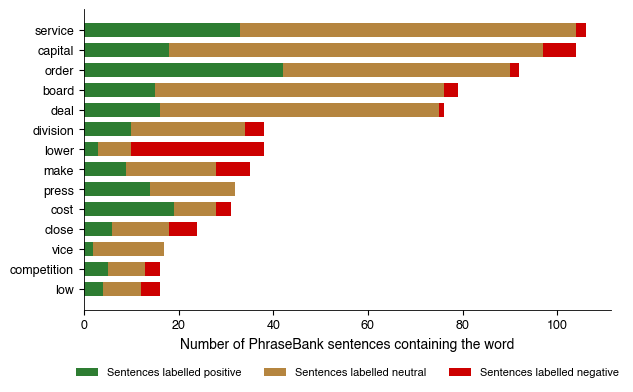

{'n_lm_neg': 2355,
 'n_lm_pos': 354,
 'n_gi_neg': 2007,
 'n_gi_pos': 1637,
 'n_only': 1552,
 'share_gi_neg_not_lm': 0.7732934728450424,
 'sent_gi_neg': 1322,
 'sent_only': 964,
 'sent_only_nonneg': 0.8931535269709544,
 'top': {'SERVICE': 106,
  'CAPITAL': 104,
  'ORDER': 92,
  'BOARD': 79,
  'DEAL': 76,
  'DIVISION': 38,
  'LOWER': 38,
  'MAKE': 35,
  'PRESS': 32,
  'COST': 31,
  'CLOSE': 24,
  'VICE': 17,
  'COMPETITION': 16,
  'LOW': 16},
 'top_nonneg': {'SERVICE': 0.9811320754716981,
  'CAPITAL': 0.9326923076923077,
  'ORDER': 0.9782608695652174,
  'BOARD': 0.9620253164556962,
  'DEAL': 0.9868421052631579,
  'DIVISION': 0.8947368421052632,
  'LOWER': 0.26315789473684215,
  'MAKE': 0.8,
  'PRESS': 1.0,
  'COST': 0.9032258064516129,
  'CLOSE': 0.75,
  'VICE': 1.0,
  'COMPETITION': 0.8125,
  'LOW': 0.75},
 'hit_lm_pb': 0.24411886091621957}

In [6]:
def fig_dict_words(top=14):
    """Cuvintele negative in Harvard IV-4, dar nu in Loughran-McDonald, cele mai frecvente in PhraseBank."""
    pb = load_phrasebank()
    D = load_dictionaries()
    only = D['GI_neg'] - D['LM_neg']
    rows = {}
    for t, l in zip(pb['text'], pb['label']):
        for w in set(tokens(t)):
            if w in only:
                r = rows.setdefault(w, {'negative': 0, 'neutral': 0, 'positive': 0})
                r[l] += 1
    f = pd.DataFrame(rows).T
    f['n'] = f.sum(1)
    f = f.sort_values('n', ascending=False).head(top)[::-1]
    fig, ax = plt.subplots(figsize=(6.8, 3.9))
    left = np.zeros(len(f))
    for l in ('positive', 'neutral', 'negative'):
        ax.barh(f.index.str.lower(), f[l], left=left, color=LAB_COL[l], label=f'Sentences labelled {l}', height=0.7)
        left += f[l].values
    ax.set_xlabel('Number of PhraseBank sentences containing the word')
    legend_outside_bottom(ax, ncol=3, y=-0.16)
    save_fig('ch15_dict_words')
    n_gi = sum(1 for t in pb['text'] if any(w in D['GI_neg'] for w in tokens(t)))
    n_only = sum(1 for t in pb['text'] if any(w in only for w in tokens(t)) and
                 not any(w in D['LM_neg'] for w in tokens(t)))
    lab_only = pb['label'][[any(w in only for w in tokens(t)) and not any(w in D['LM_neg'] for w in tokens(t))
                            for t in pb['text']]]
    RES['dict'] = {'n_lm_neg': len(D['LM_neg']), 'n_lm_pos': len(D['LM_pos']), 'n_gi_neg': len(D['GI_neg']),
                   'n_gi_pos': len(D['GI_pos']), 'n_only': len(only),
                   'share_gi_neg_not_lm': len(only) / len(D['GI_neg']),
                   'sent_gi_neg': n_gi, 'sent_only': n_only,
                   'sent_only_nonneg': float((lab_only != 'negative').mean()),
                   'top': {w: int(r['n']) for w, r in f[::-1].iterrows()},
                   'top_nonneg': {w: float(1 - r['negative'] / r['n']) for w, r in f[::-1].iterrows()},
                   'hit_lm_pb': float(np.mean([any(w in D['LM_neg'] | D['LM_pos'] for w in tokens(t))
                                               for t in pb['text']]))}


fig_dict_words()
RES['dict']

In [7]:
# Live: FinBERT and the two dictionaries on five sentences of your choice
mine = ['Operating profit rose to EUR 13.1 mn from EUR 8.7 mn a year earlier.',
        'The company expects higher tax liabilities and rising costs next year.',
        'Shares plunged after the bank cut its dividend.',
        'The board will meet on Tuesday.',
        'Net sales were in line with guidance.']
D = load_dictionaries()
P = finbert_probs(mine)
pd.DataFrame({'text': mine,
              'LM': dict_tone(mine, D['LM_pos'], D['LM_neg']).round(2),
              'GI': dict_tone(mine, D['GI_pos'], D['GI_neg']).round(2),
              'FinBERT': probs_label(P), 'P(pos) - P(neg)': net_score(P).round(3)})

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,text,LM,GI,FinBERT,P(pos) - P(neg)
0,Operating profit rose to EUR 13.1 mn from EUR ...,0.0,1.00,positive,0.926
1,The company expects higher tax liabilities and...,0.0,0.00,negative,-0.240
2,Shares plunged after the bank cut its dividend.,-1.0,-1.00,negative,-0.941
3,The board will meet on Tuesday.,0.0,0.33,neutral,-0.048
4,Net sales were in line with guidance.,0.0,0.00,positive,0.569


In [8]:
# Live (optional, downloads about 1 GB): a small LLM classifies the same five sentences zero-shot
RUN_LLM = False
if RUN_LLM:
    tok, m = llm_load('0.5B')
    Q = llm_sentiment(tok, m, mine)
    print(pd.DataFrame(Q, columns=LABELS, index=mine).round(3))

## 2. Eleven classifiers on two labelled data sets

- Accuracy with a 95% bootstrap interval, macro-F1, confusion matrices, McNemar tests.

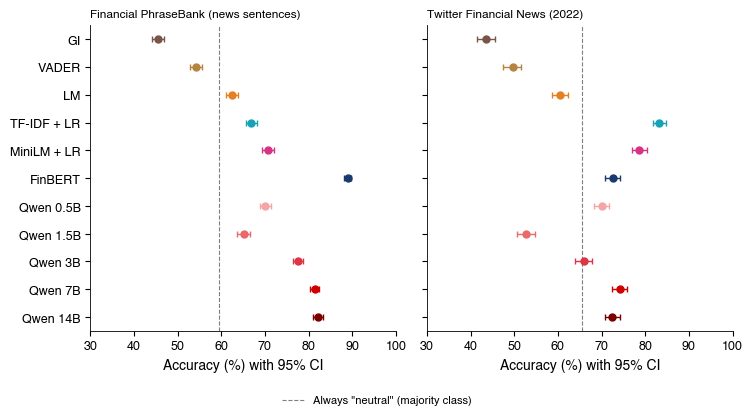

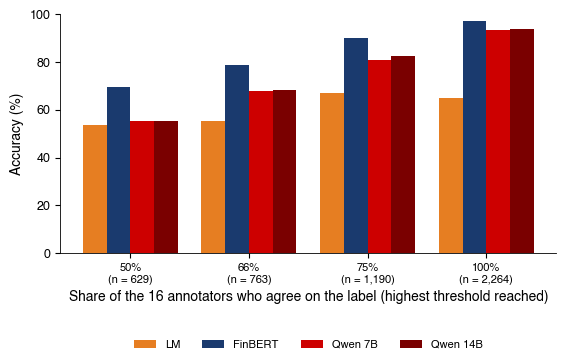

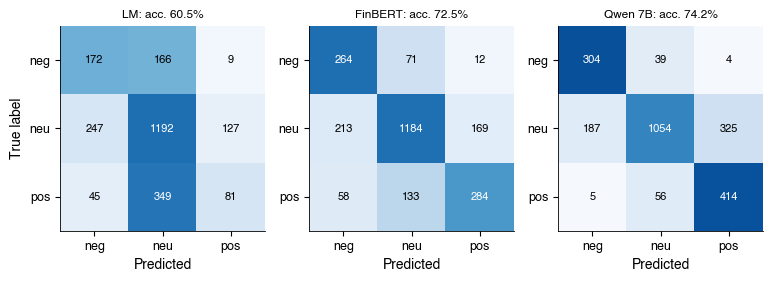

,acc,lo,hi,f1
GI,0.435511,0.415798,0.455622,0.377433
LM,0.605109,0.585427,0.623534,0.462218
VADER,0.496231,0.474037,0.515494,0.447878
TF-IDF + LR,0.832077,0.817839,0.847152,0.760461
MiniLM + LR,0.786432,0.770101,0.803183,0.699287
FinBERT,0.725293,0.706857,0.742462,0.668173
Qwen 0.5B,0.700168,0.682998,0.717755,0.640612
Qwen 1.5B,0.527219,0.507119,0.54732,0.552751
Qwen 3B,0.659966,0.639866,0.67924,0.65455
Qwen 7B,0.742044,0.724026,0.758386,0.725821


In [9]:
def eval_texts():
    pb, tw = load_csv('ch15_phrasebank_scores.csv'), load_csv('ch15_twitter_scores.csv')
    R = {'n_pb': len(pb), 'n_tw': len(tw), 'n_pb_all': int((pb['agree'] == 'AllAgree').sum())}
    for name, d in (('pb', pb), ('tw', tw)):
        y = d['label'].values
        pr = predictions(d)
        R[name] = {}
        for m, yh in pr.items():
            lo, hi = boot_ci(y, yh, acc, B=1000)
            R[name][m] = {'acc': acc(y, yh), 'lo': lo, 'hi': hi, 'f1': macro_f1(y, yh)}
        R[name]['share'] = d['label'].value_counts(normalize=True).to_dict()
        R[name]['always_neutral_f1'] = macro_f1(y, np.full(len(y), 'neutral'))
    # acordul adnotatorilor (PhraseBank)
    pr = predictions(pb)
    R['agree'] = {lvl: {m: acc(pb['label'][pb['agree'] == lvl], pr[m][pb['agree'] == lvl])
                        for m in ('LM', 'FinBERT', 'Qwen 7B', 'Qwen 14B')} for lvl in AGREE}
    R['agree_n'] = pb['agree'].value_counts().to_dict()
    # teste pe perechi (Twitter)
    y = tw['label'].values
    pt = predictions(tw)
    R['pairs'] = {}
    for a, b in (('LM', 'FinBERT'), ('FinBERT', 'Qwen 7B'), ('FinBERT', 'Qwen 14B'), ('Qwen 1.5B', 'Qwen 7B'),
                 ('FinBERT', 'MiniLM + LR')):
        n01, n10, p = mcnemar(y, pt[a], pt[b])
        lo, hi = diff_ci(y, pt[a], pt[b], B=1000)
        R['pairs'][f'{a}|{b}'] = {'n01': n01, 'n10': n10, 'p': p, 'diff': acc(y, pt[b]) - acc(y, pt[a]),
                                  'lo': lo, 'hi': hi}
    # formularea cerintei
    R['prompts'] = {}
    for s in ('1.5B', '7B', '14B'):
        labs = {p: probs_label(tw[[f'qwen{s}{"" if p == "P1" else "_" + p}_{l}' for l in LABELS]].values)
                for p in ('P1', 'P2', 'P3')}
        R['prompts'][s] = {p: {'acc': acc(y, v), 'f1': macro_f1(y, v)} for p, v in labs.items()}
        R['prompts'][s]['agree_all'] = float(np.mean((labs['P1'] == labs['P2']) & (labs['P1'] == labs['P3'])))
        R['prompts'][s]['share_neutral'] = {p: float(np.mean(v == 'neutral')) for p, v in labs.items()}
    t = load_csv('ch15_llm_time.csv', index_col=0)['sec_per_text']
    R['time'] = {k.replace('time_qwen', ''): float(v) for k, v in t.items() if '_' not in k.replace('time_qwen', '')}
    lc = load_csv('ch15_learning_curve.csv')
    R['lc'] = lc.groupby('n')[['emb_acc', 'tfidf_acc', 'emb_f1', 'tfidf_f1']].mean().to_dict('index')
    for name, d in (('pb', pb), ('tw', tw)):
        for m in ('LM', 'FinBERT', 'Qwen 7B'):
            R[name][m]['cm'] = confusion(d['label'], predictions(d)[m]).values.tolist()
    RES['texts'] = R
    return pb, tw


def fig_accuracy():
    R = RES['texts']
    fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.9), sharey=True)
    y = np.arange(len(METHODS))[::-1]
    for ax, key, title in zip(axes, ('pb', 'tw'), ('Financial PhraseBank (news sentences)',
                                                     'Twitter Financial News (2022)')):
        for yi, m in zip(y, METHODS):
            r = R[key][m]
            ax.errorbar(100 * r['acc'], yi, xerr=[[100 * (r['acc'] - r['lo'])], [100 * (r['hi'] - r['acc'])]],
                        fmt='o', color=M_COL[m], ms=5, capsize=2, lw=1)
        base = 100 * R[key]['share']['neutral']
        ax.axvline(base, color=Gray, ls='--', lw=0.8)
        ax.set_title(title, fontsize=8.5, loc='left')
        ax.set_xlabel('Accuracy (%) with 95% CI')
        ax.set_xlim(30, 100)
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(METHODS)
    h = [plt.Line2D([], [], color=Gray, ls='--', lw=0.8)]
    fig_legend_bottom(fig, h, ['Always "neutral" (majority class)'], ncol=1, y=0.0)
    fig.tight_layout()
    save_fig('ch15_accuracy')


def fig_agreement():
    R = RES['texts']['agree']
    fig, ax = plt.subplots(figsize=(6.4, 3.1))
    x = np.arange(len(AGREE))
    for k, (m, c) in enumerate((('LM', Orange), ('FinBERT', MainBlue), ('Qwen 7B', IDAred), ('Qwen 14B', '#7A0000'))):
        ax.bar(x + (k - 1.5) * 0.2, [100 * R[l][m] for l in AGREE], 0.2, color=c, label=m)
    n = RES['texts']['agree_n']
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l.replace("Agree", "")}{"%" if l != "AllAgree" else ""}\n(n = {n[l]:,})'.replace(
        'All', '100%') for l in AGREE], fontsize=8)
    ax.set_xlabel('Share of the 16 annotators who agree on the label (highest threshold reached)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    legend_outside_bottom(ax, ncol=4, y=-0.32)
    save_fig('ch15_agreement')


def fig_confusion(tw):
    fig, axes = plt.subplots(1, 3, figsize=(7.8, 2.8))
    pr = predictions(tw)
    for ax, m in zip(axes, ('LM', 'FinBERT', 'Qwen 7B')):
        cm = confusion(tw['label'], pr[m]).values
        share = cm / cm.sum(1, keepdims=True)
        ax.imshow(share, cmap='Blues', vmin=0, vmax=1)
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=8,
                        color='white' if share[i, j] > 0.55 else 'black')
        ax.set_xticks(range(3))
        ax.set_xticklabels(['neg', 'neu', 'pos'])
        ax.set_yticks(range(3))
        ax.set_yticklabels(['neg', 'neu', 'pos'])
        ax.set_title(f'{m}: acc. {100 * acc(tw["label"], pr[m]):.1f}%', fontsize=8.5)
        ax.set_xlabel('Predicted')
    axes[0].set_ylabel('True label')
    fig.tight_layout()
    save_fig('ch15_confusion')


pb, tw = eval_texts()
fig_accuracy()
fig_agreement()
fig_confusion(tw)
pd.DataFrame({k: v for k, v in RES['texts']['tw'].items() if isinstance(v, dict) and 'acc' in v}).T[['acc', 'lo', 'hi', 'f1']].round(3)

In [10]:
pd.DataFrame(RES['texts']['pairs']).T.round(4)

,n01,n10,p,diff,lo,hi
LM|FinBERT,539.0,252.0,0.0000,0.1202,0.0997,0.1415
FinBERT|Qwen 7B,395.0,355.0,0.1544,0.0168,-0.0054,0.0381
FinBERT|Qwen 14B,377.0,380.0,0.9421,-0.0013,-0.0222,0.0222
Qwen 1.5B|Qwen 7B,626.0,113.0,0.0000,0.2148,0.1939,0.2328
FinBERT|MiniLM + LR,400.0,254.0,0.0000,0.0611,0.0402,0.0821


## 3. Large language models: size and prompt wording

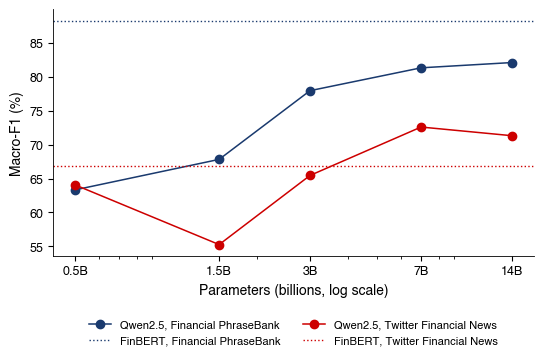

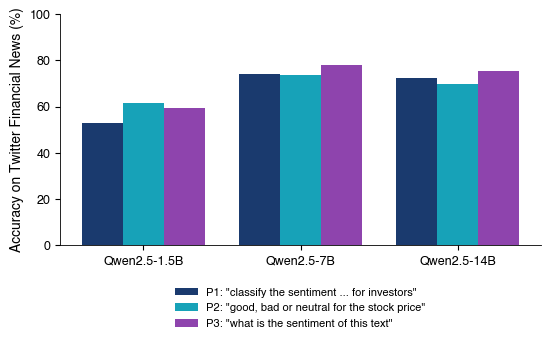

,1.5B,7B,14B
P1,"{'acc': 0.5272194304857621, 'f1': 0.5527505771...","{'acc': 0.7420435510887772, 'f1': 0.7258213002...","{'acc': 0.724036850921273, 'f1': 0.71306875013..."
P2,"{'acc': 0.6168341708542714, 'f1': 0.6265985592...","{'acc': 0.7370184254606366, 'f1': 0.7154270638...","{'acc': 0.6993299832495813, 'f1': 0.6728133024..."
P3,"{'acc': 0.5917085427135679, 'f1': 0.5776169624...","{'acc': 0.7784757118927973, 'f1': 0.7176803844...","{'acc': 0.7558626465661642, 'f1': 0.7328053289..."
agree_all,0.616415,0.671692,0.672948
share_neutral,"{'P1': 0.23241206030150754, 'P2': 0.3421273031...","{'P1': 0.48115577889447236, 'P2': 0.5067001675...","{'P1': 0.4250418760469012, 'P2': 0.51423785594..."


In [11]:
def fig_llm_size():
    R = RES['texts']
    fig, ax = plt.subplots(figsize=(6.2, 3.2))
    xs = list(SIZES_B.values())
    for key, c, lab in (('pb', MainBlue, 'Financial PhraseBank'), ('tw', IDAred, 'Twitter Financial News')):
        ax.plot(xs, [100 * R[key][f'Qwen {s}']['f1'] for s in SIZES_B], 'o-', color=c, label=f'Qwen2.5, {lab}')
        ax.axhline(100 * R[key]['FinBERT']['f1'], color=c, ls=':', lw=1, label=f'FinBERT, {lab}')
    ax.set_xscale('log')
    ax.set_xticks(xs)
    ax.set_xticklabels([f'{s}' for s in SIZES_B])
    ax.set_xlabel('Parameters (billions, log scale)')
    ax.set_ylabel('Macro-F1 (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    save_fig('ch15_llm_size')


def fig_prompts():
    R = RES['texts']['prompts']
    fig, ax = plt.subplots(figsize=(6.2, 3.0))
    x = np.arange(3)
    for k, (p, c) in enumerate((('P1', MainBlue), ('P2', Teal), ('P3', Purple))):
        ax.bar(x + (k - 1) * 0.26, [100 * R[s][p]['acc'] for s in ('1.5B', '7B', '14B')], 0.26, color=c,
               label={'P1': 'P1: "classify the sentiment ... for investors"',
                      'P2': 'P2: "good, bad or neutral for the stock price"',
                      'P3': 'P3: "what is the sentiment of this text"'}[p])
    ax.set_xticks(x)
    ax.set_xticklabels(['Qwen2.5-1.5B', 'Qwen2.5-7B', 'Qwen2.5-14B'])
    ax.set_ylabel('Accuracy on Twitter Financial News (%)')
    ax.set_ylim(0, 100)
    legend_outside_bottom(ax, ncol=1, y=-0.14)
    save_fig('ch15_prompts')


fig_llm_size()
fig_prompts()
pd.DataFrame(RES['texts']['prompts'])

## 4. Embeddings as features

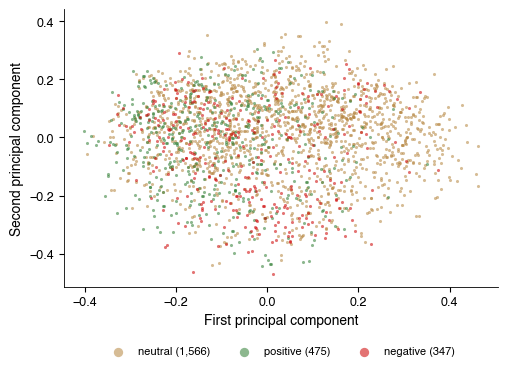

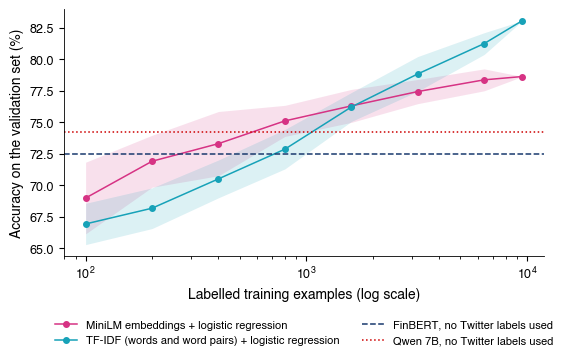

,emb_acc,tfidf_acc,emb_f1,tfidf_f1
100,0.690,0.669,0.433,0.327
200,0.719,0.682,0.539,0.380
400,0.733,0.705,0.586,0.446
800,0.751,0.729,0.630,0.521
1600,0.763,0.762,0.661,0.613
3200,0.774,0.788,0.681,0.675
6400,0.784,0.813,0.695,0.722
9543,0.786,0.831,0.699,0.755


In [12]:
def fig_embeddings(tw):
    fig, ax = plt.subplots(figsize=(5.6, 3.6))
    for l in ('neutral', 'positive', 'negative'):
        q = tw[tw['label'] == l]
        ax.scatter(q['pc1'], q['pc2'], s=5, alpha=0.55, color=LAB_COL[l], label=f'{l} ({len(q):,})', lw=0)
    ax.set_xlabel('First principal component')
    ax.set_ylabel('Second principal component')
    legend_outside_bottom(ax, ncol=3, y=-0.18, markerscale=3)
    save_fig('ch15_embeddings')


def fig_learning_curve():
    lc = load_csv('ch15_learning_curve.csv')
    grp = lc.groupby('n')
    m, s = grp.mean(), grp.std().fillna(0)
    R = RES['texts']['tw']
    fig, ax = plt.subplots(figsize=(6.2, 3.2))
    for k, c, lab in (('emb', Magenta, 'MiniLM embeddings + logistic regression'),
                      ('tfidf', Teal, 'TF-IDF (words and word pairs) + logistic regression')):
        ax.plot(m.index, 100 * m[f'{k}_acc'], 'o-', color=c, label=lab, ms=4)
        ax.fill_between(m.index, 100 * (m[f'{k}_acc'] - 2 * s[f'{k}_acc']), 100 * (m[f'{k}_acc'] + 2 * s[f'{k}_acc']),
                        color=c, alpha=0.15, lw=0)
    for mm, c, ls in (('FinBERT', MainBlue, '--'), ('Qwen 7B', IDAred, ':')):
        ax.axhline(100 * R[mm]['acc'], color=c, ls=ls, lw=1.1, label=f'{mm}, no Twitter labels used')
    ax.set_xscale('log')
    ax.set_xlabel('Labelled training examples (log scale)')
    ax.set_ylabel('Accuracy on the validation set (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    save_fig('ch15_learning_curve')


fig_embeddings(tw)
fig_learning_curve()
pd.DataFrame(RES['texts']['lc']).T.round(3)

## 5. Look-ahead bias: does the model already know the answer?

- Qwen2.5 is asked, with no context, whether the S&P 500 rose or fell in a given month, and whether Apple rose or fell on a given day.
- AUC before and after the release of the weights (19 September 2024).

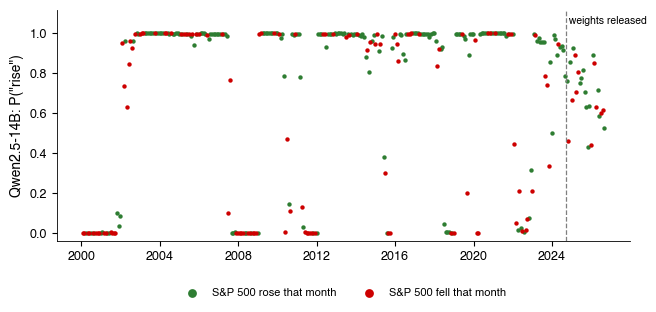

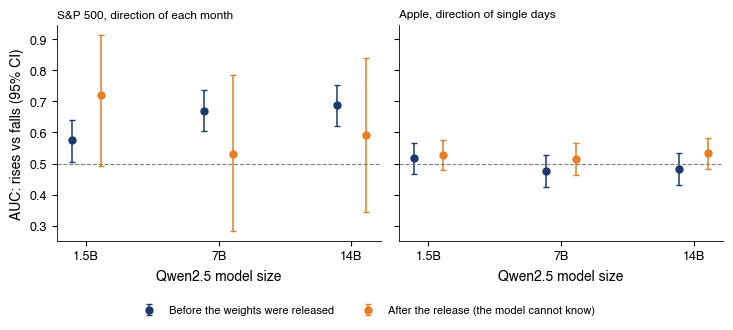

,1.5B,7B,14B
pre,"{'auc': 0.5745556367177989, 'lo': 0.5059686091...","{'auc': 0.6700267835402971, 'lo': 0.6056984737...","{'auc': 0.6872656440224008, 'lo': 0.6221625099..."
post,"{'auc': 0.7192307692307692, 'lo': 0.4924213286...","{'auc': 0.5307692307692308, 'lo': 0.2833333333...","{'auc': 0.5923076923076923, 'lo': 0.3451388888..."


In [13]:
def stats_auc(a, b):
    from scipy.stats import mannwhitneyu
    if len(a) == 0 or len(b) == 0:
        return np.nan
    return mannwhitneyu(a, b).statistic / (len(a) * len(b))


def auc(p, up):
    p, up = np.asarray(p), np.asarray(up, bool)
    return float(stats_auc(p[up], p[~up]))


def boot_auc(p, up, B=2000, seed=0):
    rng = np.random.default_rng(seed)
    p, up = np.asarray(p), np.asarray(up, bool)
    v = []
    for _ in range(B):
        i = rng.integers(0, len(p), len(p))
        if up[i].all() or (~up[i]).all():
            continue
        v.append(stats_auc(p[i][up[i]], p[i][~up[i]]))
    return tuple(np.quantile(v, [0.025, 0.975]))


def eval_memory():
    mm = load_csv('ch15_memory_monthly.csv', index_col=0, parse_dates=True)
    md = load_csv('ch15_memory_daily.csv', index_col=0, parse_dates=True)
    R = {}
    for name, d, cut_pre, cut_post in (('monthly', mm, '2024-08-31', '2024-10-01'),
                                       ('daily', md, '2023-12-31', '2024-10-01')):
        up = d['ret'] > 0
        R[name] = {}
        for s in ('1.5B', '7B', '14B'):
            col = f'qwen{s}'
            r = {}
            for per, sel in (('pre', d.index <= cut_pre), ('post', d.index >= cut_post)):
                p, u = d.loc[sel, col].values, up[sel].values
                lo, hi = boot_auc(p, u)
                ba = 0.5 * (np.mean(p[u] > 0.5) + np.mean(p[~u] <= 0.5))
                r[per] = {'auc': auc(p, u), 'lo': lo, 'hi': hi, 'ba': float(ba), 'n': int(sel.sum()),
                          'n_up': int(u.sum()), 'p_rise': float(np.mean(p > 0.5))}
            R[name][s] = r
    # lunile cele mai cunoscute
    pre = mm.loc[:'2024-08-31']
    worst = pre.nsmallest(8, 'ret')
    R['worst'] = {d.strftime('%Y-%m'): {'ret': float(r['ret']), 'p14': float(r['qwen14B'])} for d, r in worst.iterrows()}
    R['range'] = {'m_start': mm.index[0].strftime('%Y-%m'), 'm_end': mm.index[-1].strftime('%Y-%m'),
                  'd_pre_start': md.index[0].strftime('%Y-%m-%d')}
    RES['memory'] = R
    return mm, md


def fig_memory_timeline(mm):
    fig, ax = plt.subplots(figsize=(7.4, 3.0))
    up = mm['ret'] > 0
    ax.scatter(mm.index[up], mm.loc[up, 'qwen14B'], s=10, color=Forest, label='S&P 500 rose that month', lw=0)
    ax.scatter(mm.index[~up], mm.loc[~up, 'qwen14B'], s=10, color=IDAred, label='S&P 500 fell that month', lw=0)
    ax.axvline(pd.Timestamp(QWEN_RELEASE), color=Gray, ls='--', lw=0.9)
    ax.text(pd.Timestamp(QWEN_RELEASE), 1.04, ' weights released', fontsize=7.5, color='black', va='bottom')
    ax.set_ylabel('Qwen2.5-14B: P("rise")')
    ax.set_ylim(-0.04, 1.12)
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    legend_outside_bottom(ax, ncol=2, y=-0.16, markerscale=2)
    save_fig('ch15_memory_timeline')


def fig_memory_auc():
    R = RES['memory']
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), sharey=True)
    for ax, name, title in zip(axes, ('monthly', 'daily'), ('S&P 500, direction of each month',
                                                             'Apple, direction of single days')):
        x = np.arange(3)
        for k, (per, c, lab) in enumerate((('pre', MainBlue, 'Before the weights were released'),
                                          ('post', Orange, 'After the release (the model cannot know)'))):
            vals = [R[name][s][per] for s in ('1.5B', '7B', '14B')]
            ax.errorbar(x + (k - 0.5) * 0.22, [v['auc'] for v in vals],
                        yerr=[[v['auc'] - v['lo'] for v in vals], [v['hi'] - v['auc'] for v in vals]],
                        fmt='o', color=c, capsize=2, ms=5, label=lab)
        ax.axhline(0.5, color=Gray, ls='--', lw=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(['1.5B', '7B', '14B'])
        ax.set_title(title, fontsize=8.5, loc='left')
        ax.set_xlabel('Qwen2.5 model size')
    axes[0].set_ylabel('AUC: rises vs falls (95% CI)')
    h, l = axes[0].get_legend_handles_labels()
    fig.tight_layout()
    fig_legend_bottom(fig, h, l, ncol=2, y=0.0)
    save_fig('ch15_memory_auc')


mm, md = eval_memory()
fig_memory_timeline(mm)
fig_memory_auc()
pd.DataFrame(RES['memory']['monthly']).round(3)

## 6. From headline sentiment to a trading signal (FNSPID)

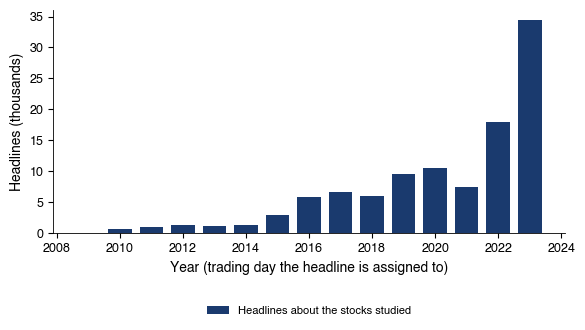

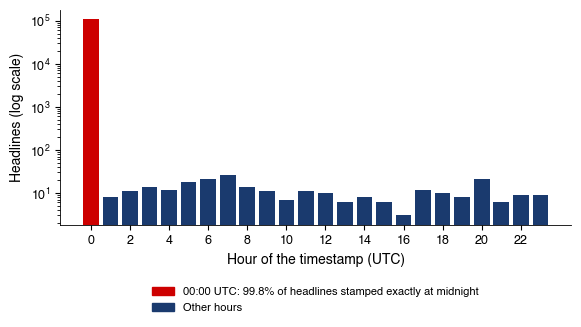

In [14]:
def fig_news_coverage():
    cnt = load_csv('ch15_news_counts.csv', index_col=0)
    tot = cnt.sum(1)
    fig, ax = plt.subplots(figsize=(6.6, 2.9))
    ax.bar(tot.index.astype(int), tot.values / 1e3, color=MainBlue, width=0.75, label='Headlines about the stocks studied')
    ax.set_ylabel('Headlines (thousands)')
    ax.set_xlabel('Year (trading day the headline is assigned to)')
    legend_outside_bottom(ax, ncol=1, y=-0.28)
    save_fig('ch15_news_coverage')


def fig_news_hours():
    h = load_csv('ch15_news_hours.csv', index_col=0)
    fig, ax = plt.subplots(figsize=(6.6, 2.8))
    ax.bar(h.index, h['n'], color=[IDAred if x == 0 else MainBlue for x in h.index], width=0.8)
    ax.set_yscale('log')
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlabel('Hour of the timestamp (UTC)')
    ax.set_ylabel('Headlines (log scale)')
    h1 = [plt.Rectangle((0, 0), 1, 1, color=IDAred), plt.Rectangle((0, 0), 1, 1, color=MainBlue)]
    ax.legend(h1, [f'00:00 UTC: {100 * h["share_midnight"].iloc[0]:.1f}% of headlines stamped exactly at midnight',
                   'Other hours'], loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=1, frameon=False)
    RES.setdefault('news', {})['midnight'] = float(h['share_midnight'].iloc[0])
    save_fig('ch15_news_hours')


fig_news_coverage()
fig_news_hours()

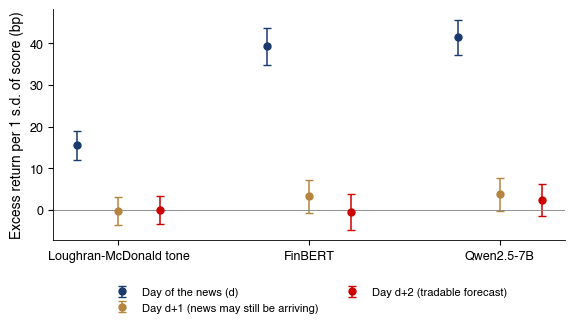

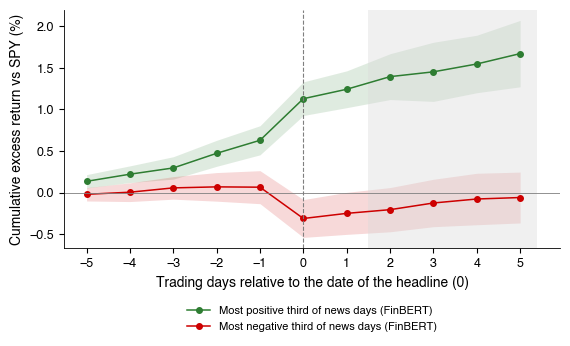

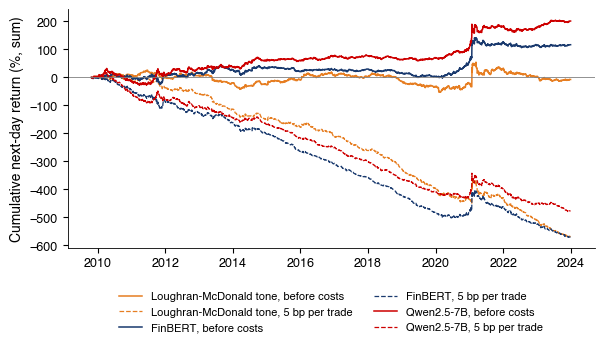

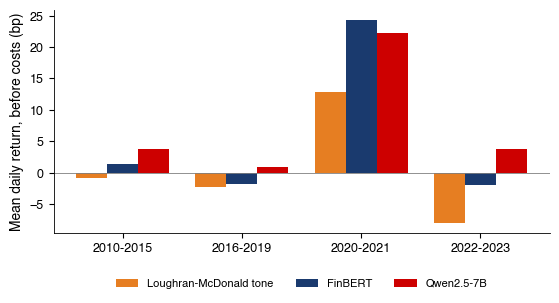

,b,se_ols,se_cl,t_ols,t_cl
lm|r0,0.1547,0.0232,0.0181,6.6570,8.5343
lm|r1,-0.0037,0.0223,0.0171,-0.1635,-0.2135
lm|r2,-0.0003,0.0218,0.0174,-0.0118,-0.0148
finbert|r0,0.3923,0.0231,0.0227,16.9879,17.2712
finbert|r1,0.0318,0.0223,0.0199,1.4262,1.6002
finbert|r2,-0.0054,0.0218,0.0215,-0.2460,-0.2491
qwen|r0,0.4145,0.0231,0.0217,17.9649,19.0684
qwen|r1,0.0369,0.0223,0.0198,1.6547,1.8619
qwen|r2,0.0232,0.0218,0.0194,1.0621,1.1945


In [15]:
def news_panel():
    daily = load_csv('ch15_news_daily.csv', parse_dates=['day']).set_index(['day', 'ticker'])
    syms = sorted(set(TICKERS.values()))
    rets = stock_returns(syms + ['SPY.US'], start='2009-01-01')
    rets.columns = [c.replace('.US', '') for c in rets.columns]
    rets = rets.loc[:'2023-12-31']
    P = daily_panel(daily, rets)
    for c in SCORE_LBL:
        P[f'z_{c}'] = (P[c] - P[c].mean()) / P[c].std()
    return P, rets


def eval_news(P, rets):
    cnt = load_csv('ch15_news_counts.csv', index_col=0)
    hl = load_csv('ch15_news_headlines.csv.gz', usecols=['finbert', 'lm', 'lm_hit', 'qwen', 'finbert_lab'])
    R = {'n_headlines': int(cnt.values.sum()), 'n_tickers': int((cnt.sum() > 0).sum()),
         'n_obs': len(P), 'n_days': int(P.index.get_level_values('day').nunique()),
         'first': str(P.index.get_level_values('day').min().date()),
         'last': str(P.index.get_level_values('day').max().date()),
         'per_year': cnt.sum(1).to_dict(), 'per_ticker': cnt.sum().sort_values(ascending=False).to_dict(),
         'mean_n': float(P['n'].mean()), 'lm_hit': float(hl['lm_hit'].mean()),
         'fb_share': (hl['finbert_lab'].value_counts(normalize=True).sort_index()).tolist(),
         'corr': hl[['lm', 'finbert', 'qwen']].corr().round(3).to_dict(),
         'corr_daily': P[['lm', 'finbert', 'qwen']].corr().round(3).to_dict()}
    R['reg'] = {}
    groups = P.index.get_level_values('day')
    for c in SCORE_LBL:
        for y in ('r0', 'r1', 'r2'):
            R['reg'][f'{c}|{y}'] = {k: float(v) for k, v in cluster_ols(P[y].values, P[f'z_{c}'].values,
                                                                           groups).items()}
    # studiul de eveniment: tercilele scorului FinBERT
    cols = EVENT_COLS
    R['event'] = {}
    for c in ('finbert', 'qwen', 'lm'):
        q1, q2 = P[c].quantile([1 / 3, 2 / 3])
        ev = {}
        for grp, sel in (('neg', P[c] <= q1), ('pos', P[c] >= q2)):
            X = P.loc[sel, cols].groupby(level='day').mean()
            car = X.fillna(0).cumsum(axis=1)
            ev[grp] = {'car': car.mean().tolist(), 'se': (car.std() / np.sqrt(len(car))).tolist(), 'n_days': len(X),
                       'n': int(sel.sum())}
        R['event'][c] = ev
    # strategia
    days = rets.index[(rets.index >= P.index.get_level_values('day').min())]
    R['strat'] = {}
    for c in SCORE_LBL:
        St = signal_portfolio(P, c, days, cost_bp=5, ret='r2')
        S1 = signal_portfolio(P, c, days, ret='r1')
        m1, t1 = nw_t(S1['gross'])
        mu, t = nw_t(St['gross'])
        lo, hi = block_boot_mean(St['gross'].values)
        mun, tn = nw_t(St['net'])
        active = St['k'] > 0
        R['strat'][c] = {'mean_bp': 1e2 * mu, 't': t, 'lo_bp': 1e2 * lo, 'hi_bp': 1e2 * hi,
                         'sr': sharpe(St['gross']), 'sr_net': sharpe(St['net']), 't_net': tn,
                         'mean_net_bp': 1e2 * mun, 'active': float(active.mean()),
                         'mean_active_bp': 1e2 * St.loc[active, 'gross'].mean(),
                         'breakeven_bp': 1e2 * St.loc[active, 'gross'].mean() / 4,
                         'r1_mean_bp': 1e2 * m1, 'r1_t': t1, 'r1_sr': sharpe(S1['gross']),
                         'years': {}}
        for a, b in PERIODS:
            x = St.loc[a:b, 'gross']
            m_, t_ = nw_t(x)
            R['strat'][c]['years'][f'{a}-{b}'] = {'mean_bp': 1e2 * m_, 't': t_}
        R['strat'][c]['cum'] = St[['gross', 'net']]
    RES['news'] = R
    return P


def fig_contemp_next():
    R = RES['news']['reg']
    fig, ax = plt.subplots(figsize=(6.6, 3.0))
    x = np.arange(len(SCORE_LBL))
    for k, (y, c, lab) in enumerate((('r0', MainBlue, 'Day of the news (d)'),
                                     ('r1', Amber, 'Day d+1 (news may still be arriving)'),
                                     ('r2', IDAred, 'Day d+2 (tradable forecast)'))):
        b = [100 * R[f'{s}|{y}']['b'] for s in SCORE_LBL]
        e = [1.96 * 100 * R[f'{s}|{y}']['se_cl'] for s in SCORE_LBL]
        ax.errorbar(x + (k - 1) * 0.22, b, yerr=e, fmt='o', color=c, capsize=3, ms=5, label=lab)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([SCORE_LBL[s] for s in SCORE_LBL])
    ax.set_ylabel('Excess return per 1 s.d. of score (bp)')
    legend_outside_bottom(ax, ncol=2, y=-0.16)
    save_fig('ch15_contemp_next')


def fig_event_study():
    R = RES['news']['event']['finbert']
    k = np.arange(-5, 6)
    fig, ax = plt.subplots(figsize=(6.4, 3.1))
    for grp, c, lab in (('pos', Forest, 'Most positive third of news days (FinBERT)'),
                        ('neg', IDAred, 'Most negative third of news days (FinBERT)')):
        car, se = np.array(R[grp]['car']), np.array(R[grp]['se'])
        ax.plot(k, car, 'o-', color=c, label=lab, ms=4)
        ax.fill_between(k, car - 1.96 * se, car + 1.96 * se, color=c, alpha=0.15, lw=0)
    ax.axvline(0, color=Gray, ls='--', lw=0.8)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xticks(k)
    ax.axvspan(1.5, 5.4, color=LightGray, alpha=0.4, lw=0)
    ax.set_xlabel('Trading days relative to the date of the headline (0)')
    ax.set_ylabel('Cumulative excess return vs SPY (%)')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch15_event_study')


def fig_strategy():
    R = RES['news']['strat']
    fig, ax = plt.subplots(figsize=(6.8, 3.1))
    for c in SCORE_LBL:
        St = R[c]['cum']
        ax.plot(St.index, St['gross'].cumsum(), color=SCORE_COL[c], lw=1.1, label=f'{SCORE_LBL[c]}, before costs')
        ax.plot(St.index, St['net'].cumsum(), color=SCORE_COL[c], lw=0.9, ls='--', label=f'{SCORE_LBL[c]}, 5 bp per trade')
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_ylabel('Cumulative next-day return (%, sum)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch15_strategy')


def fig_subperiods():
    R = RES['news']['strat']
    per = list(R['finbert']['years'])
    fig, ax = plt.subplots(figsize=(6.4, 2.9))
    x = np.arange(len(per))
    for k, c in enumerate(SCORE_LBL):
        ax.bar(x + (k - 1) * 0.26, [R[c]['years'][p]['mean_bp'] for p in per], 0.26, color=SCORE_COL[c],
               label=SCORE_LBL[c])
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(per)
    ax.set_ylabel('Mean daily return, before costs (bp)')
    legend_outside_bottom(ax, ncol=3, y=-0.16)
    save_fig('ch15_subperiods')


P, rets = news_panel()
eval_news(P, rets)
fig_contemp_next()
fig_event_study()
fig_strategy()
fig_subperiods()
pd.DataFrame(RES['news']['reg']).T[['b', 'se_ols', 'se_cl', 't_ols', 't_cl']].round(4)

In [16]:
pd.DataFrame({c: {k: v for k, v in RES['news']['strat'][c].items() if k not in ('years', 'cum')} for c in SCORE_LBL}).round(3)

,lm,finbert,qwen
mean_bp,-0.208,3.270,5.639
t,-0.071,1.273,2.263
lo_bp,-5.313,-1.505,0.945
hi_bp,6.329,8.932,10.605
sr,-0.018,0.362,0.625
sr_net,-1.399,-1.769,-1.481
t_net,-5.399,-6.215,-5.369
mean_net_bp,-15.920,-15.979,-13.363
active,0.786,0.962,0.950
mean_active_bp,-0.265,3.398,5.935
